In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import pyviper 
import acdc_py as acdc

/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata

In [2]:
data_path = "/shares/vasciaveo_lab/data/nepc_organoid_project/new_data/MJ005/filtered_feature_bc_matrix"

# Load the 10X Genomics formatted data
adata = sc.read_10x_mtx(
    data_path,              # Directory with the matrix.mtx, barcodes.tsv, genes.tsv files
    var_names='gene_symbols',  # Use gene symbols as variable names
    cache=True                 # Cache the result for faster loading next time
)
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [3]:
net = pyviper.pp.aracne3_to_regulon(net_file='/shares/vasciaveo_lab/data/nepc_organoid_project/new_data/MJ005/aracne3_output_tfs_and_cotfs_100subnet/consolidated-net_MJ005.tsv')

In [4]:
net_pyviper = pyviper.Interactome(".", net)
# net_pyviper.net_table.sort_values(by='mor', ascending=False, inplace=False)

In [5]:
adata.X

<4544x31053 sparse matrix of type '<class 'numpy.float32'>'
	with 17305125 stored elements in Compressed Sparse Column format>

In [6]:
net_pyviper.prune(max_targets=50)
net_pyviper.net_table.value_counts('regulator')

Removed 0 targets.
Removed 0 regulators.


/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/pyviper/interactome.py:594: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pruned_df = sorted_df.groupby('regulator', group_keys=False).apply(lambda x: x.iloc[:max_targets])


regulator
0610010K14Rik    50
Setd7            50
Sertad3          50
Set              50
Setbp1           50
                 ..
Hsbp1l1          50
Hsf1             50
Hsf2             50
Hsf4             50
Zzz3             50
Name: count, Length: 2532, dtype: int64

In [7]:
viperdata = pyviper.viper(adata, net_pyviper)

Preparing the association scores
Computing regulons enrichment with aREA


/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/pyviper/aREA/aREA_classic.py:91: UserWarning: interactome "." contains 6 targets missing from gex_data.var.
	Please run interactome.filter_targets(gex_data.var_names) on your network to
	resolve this. It is highly recommend to do this on the unPruned network and
	then prune to the pruned network contains a consistent number of targets per
	regulator, allow of which exist within gex_data.
  warnings.warn(


Removed 59 targets.
Rank transforming the data
Preparing the 1-tailed / 2-tailed matrices
Computing the likelihood matrix
Computing the modes matrix
Computing 2-tail enrichment
Computing 1-tail enrichment
Integrating enrichment


In [8]:
viperdata.write_h5ad('/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/pyviperdata/viperdata_MJ005.h5ad')

In [8]:
sc.tl.pca(viperdata, n_comps = 50)

acdc.config.set_clust_alg(clust_alg='Louvain')
acdc.config.set_corr_distance_dtype(dtype=np.float64)

acdc.GS(
    viperdata,
    reduction_slot="X_pca",
    metrics=['sil_mean', 'sil_mean_median'],
    opt_metric="sil_mean_median",
    njobs=-1,
    NN_vector=[2,5,10,15,20,30],
    res_vector=np.arange(0.01, 5.0, step=0.05),
    dist_slot=None,
    key_added="pyviper_acdc_clusters"
)


Computing distance object...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 21.51it/s]


Computing neighbors...


/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata

Beginning GridSearch clustering...


/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/anndata

/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lgolinelli/miniconda3/envs/acdc_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


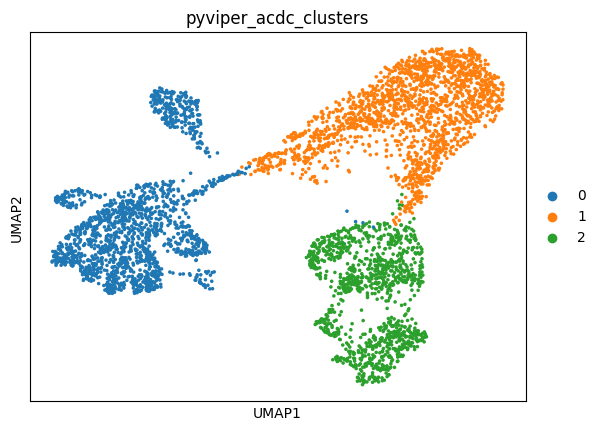

In [9]:
sc.pp.neighbors(viperdata)
sc.tl.umap(viperdata)
sc.pl.umap(viperdata, color=['pyviper_acdc_clusters'])

In [10]:
adata.obs['pyviper_acdc_clusters'] = viperdata.obs['pyviper_acdc_clusters']

In [11]:
adata

AnnData object with n_obs × n_vars = 4544 × 31053
    obs: 'pyviper_acdc_clusters'
    var: 'gene_ids'
    uns: 'log1p'
    layers: 'counts'

In [12]:
adata.layers['counts']

<4544x31053 sparse matrix of type '<class 'numpy.float32'>'
	with 17305125 stored elements in Compressed Sparse Column format>

In [16]:
adata.X = adata.layers['counts']

/tmp/ipykernel_2515104/2437277837.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = df.groupby('cluster')['expr'].mean().reindex(clusters)
/tmp/ipykernel_2515104/2437277837.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = df.groupby('cluster')['expr'].mean().reindex(clusters)
/tmp/ipykernel_2515104/2437277837.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = df.groupby('clust

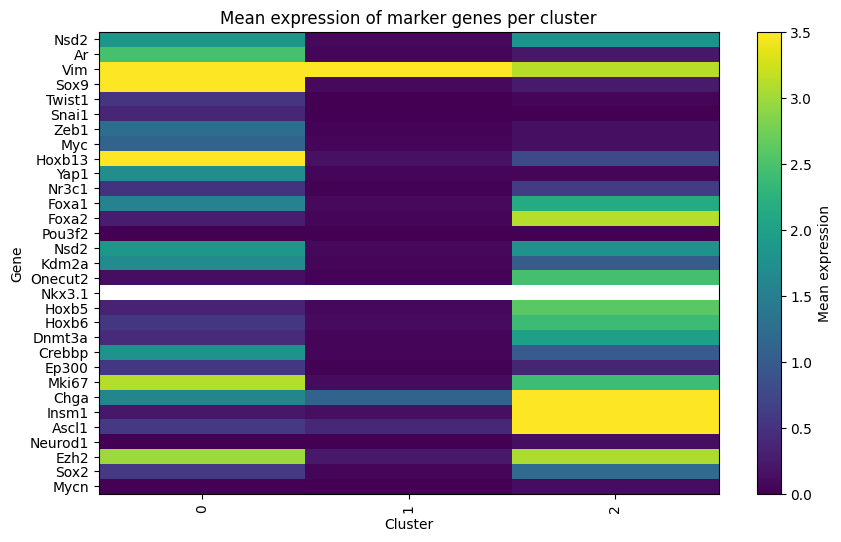

In [17]:
import matplotlib.pyplot as plt

marker_genes = [
    'Nsd2','Ar','Vim','Sox9','Twist1','Snai1','Zeb1','Myc','Hoxb13','Yap1','Nr3c1',"Foxa1","Foxa2","Pou3f2", 
    "Nsd2",'Kdm2a','Onecut2','Nkx3.1','Hoxb5','Hoxb6', "Dnmt3a","Crebbp","Ep300","Mki67" ,
    'Chga','Insm1','Ascl1',"Neurod1","Ezh2",'Sox2','Mycn']

means = []
clusters = adata.obs['pyviper_acdc_clusters'].unique()
clusters = sorted(clusters, key=lambda x: int(x) if str(x).isdigit() else x)

for gene in marker_genes:
    if gene in adata.var_names:
        expr = adata[:, gene].X
        if hasattr(expr, "toarray"):
            expr = expr.toarray().flatten()
        df = pd.DataFrame({'expr': expr, 'cluster': adata.obs['pyviper_acdc_clusters']})
        mean_expr = df.groupby('cluster')['expr'].mean().reindex(clusters)
        means.append(mean_expr.values)
    else:
        means.append([np.nan] * len(clusters))

means = np.array(means)

plt.figure(figsize=(10, 6))
plt.imshow(means, aspect='auto', cmap='viridis', vmin=0, vmax=3.5)
plt.colorbar(label='Mean expression')
plt.xticks(ticks=np.arange(len(clusters)), labels=clusters, rotation=90)
plt.yticks(ticks=np.arange(len(marker_genes)), labels=marker_genes)
plt.xlabel('Cluster')
plt.ylabel('Gene')
plt.title('Mean expression of marker genes per cluster')
plt.show()

/tmp/ipykernel_2515104/3942463889.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = df.groupby('cluster')['expr'].mean().reindex(clusters)
/tmp/ipykernel_2515104/3942463889.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = df.groupby('cluster')['expr'].mean().reindex(clusters)
/tmp/ipykernel_2515104/3942463889.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = df.groupby('clust

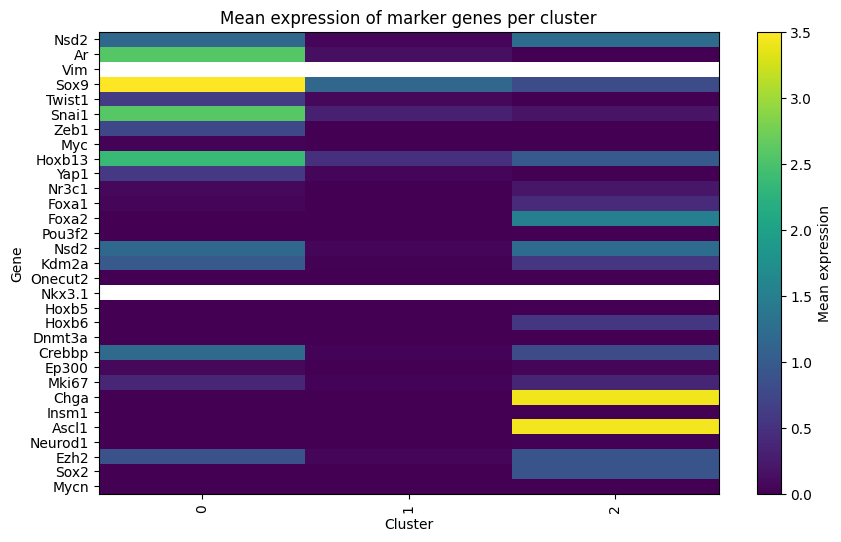

In [19]:
import matplotlib.pyplot as plt

marker_genes = [
    'Nsd2','Ar','Vim','Sox9','Twist1','Snai1','Zeb1','Myc','Hoxb13','Yap1','Nr3c1',"Foxa1","Foxa2","Pou3f2", 
    "Nsd2",'Kdm2a','Onecut2','Nkx3.1','Hoxb5','Hoxb6', "Dnmt3a","Crebbp","Ep300","Mki67" ,
    'Chga','Insm1','Ascl1',"Neurod1","Ezh2",'Sox2','Mycn']

means = []
clusters = viperdata.obs['pyviper_acdc_clusters'].unique()
clusters = sorted(clusters, key=lambda x: int(x) if str(x).isdigit() else x)

for gene in marker_genes:
    if gene in viperdata.var_names:
        expr = viperdata[:, gene].X
        if hasattr(expr, "toarray"):
            expr = expr.toarray().flatten()
        df = pd.DataFrame({'expr': expr, 'cluster': viperdata.obs['pyviper_acdc_clusters']})
        mean_expr = df.groupby('cluster')['expr'].mean().reindex(clusters)
        means.append(mean_expr.values)
    else:
        means.append([np.nan] * len(clusters))

means = np.array(means)

plt.figure(figsize=(10, 6))
plt.imshow(means, aspect='auto', cmap='viridis', vmin=0, vmax=3.5)
plt.colorbar(label='Mean expression')
plt.xticks(ticks=np.arange(len(clusters)), labels=clusters, rotation=90)
plt.yticks(ticks=np.arange(len(marker_genes)), labels=marker_genes)
plt.xlabel('Cluster')
plt.ylabel('Gene')
plt.title('Mean expression of marker genes per cluster')
plt.show()

In [18]:
#viperdata.write_h5ad('/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/pyviperdata/viperdata.h5ad')